<a href="https://colab.research.google.com/github/amnamuqudas/diabetes-predictive-analytics/blob/main/Diabetes_Predictive_Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🩺 Diabetes Prediction — Predictive Analytics Project
**ISOM 835 | Amna Muqudas**


**Dataset:** Pima Indians Diabetes Database (UCI / Kaggle)  
**Goal:** Predict whether a patient has diabetes based on diagnostic measurements  
**Target Variable:** `Outcome` (0 = No Diabetes, 1 = Diabetes)

---
### 📋 Notebook Structure
1. Imports & Data Loading
2. Exploratory Data Analysis (EDA)
3. Data Cleaning & Preprocessing
4. Model Building & Evaluation
5. Business Insights & Conclusions

---
## 1. Imports & Data Loading

In [ ]:
# ── Core Libraries ──────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ── Sklearn ──────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, roc_auc_score, roc_curve
)

# ── Settings ─────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.float_format', '{:.2f}'.format)


In [ ]:
# Load dataset directly from URL (no download needed)
url = 'https://raw.githubusercontent.com/plotly/datasets/master/diabetes.csv'
df = pd.read_csv(url)

print('Dataset shape:', df.shape)
print('\nFirst 5 rows:')
df.head()

Dataset shape: (768, 9)

First 5 rows:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.60,0.63,50,1
1,1,85,66,29,0,26.60,0.35,31,0
2,8,183,64,0,0,23.30,0.67,32,1
3,1,89,66,23,94,28.10,0.17,21,0
4,0,137,40,35,168,43.10,2.29,33,1


---
## 2. Exploratory Data Analysis (EDA)

In this section we explore the structure, distributions, and relationships in the data before any cleaning or modeling.

In [ ]:
# ── 2.1 Basic Info ───────────────────────────────────────────────
print('=== Data Types ===')
print(df.dtypes)
print('\n=== Missing Values ===')
print(df.isnull().sum())
print('\n=== Summary Statistics ===')
df.describe()

=== Data Types ===
Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

=== Missing Values ===
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

=== Summary Statistics ===


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,3.85,120.89,69.11,20.54,79.80,31.99,0.47,33.24,0.35
std,3.37,31.97,19.36,15.95,115.24,7.88,0.33,11.76,0.48
min,0.00,0.00,0.00,0.00,0.00,0.00,0.08,21.00,0.00
25%,1.00,99.00,62.00,0.00,0.00,27.30,0.24,24.00,0.00
50%,3.00,117.00,72.00,23.00,30.50,32.00,0.37,29.00,0.00
75%,6.00,140.25,80.00,32.00,127.25,36.60,0.63,41.00,1.00
max,17.00,199.00,122.00,99.00,846.00,67.10,2.42,81.00,1.00


Target Distribution:
Outcome
0    500
1    268
Name: count, dtype: int64

Diabetes rate: 34.9%


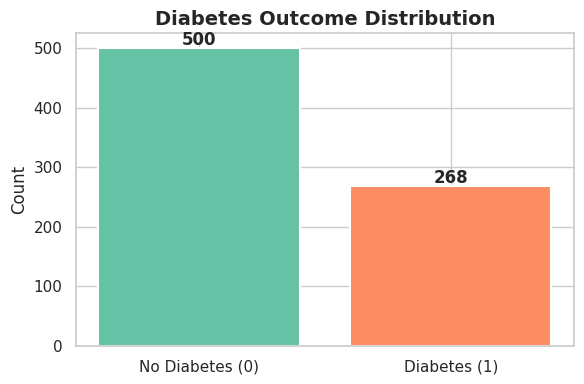

In [ ]:
# ── 2.2 Target Class Distribution ───────────────────────────────
print('Target Distribution:')
print(df['Outcome'].value_counts())
print(f"\nDiabetes rate: {df['Outcome'].mean()*100:.1f}%")

fig, ax = plt.subplots(figsize=(6, 4))
counts = df['Outcome'].value_counts()
bars = ax.bar(['No Diabetes (0)', 'Diabetes (1)'], counts.values,
              color=['#66c2a5', '#fc8d62'], edgecolor='white', linewidth=1.5)
for bar, count in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(count), ha='center', fontweight='bold')
ax.set_title('Diabetes Outcome Distribution', fontsize=14, fontweight='bold')
ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig('plot_01_class_distribution.png', bbox_inches='tight')
plt.show()

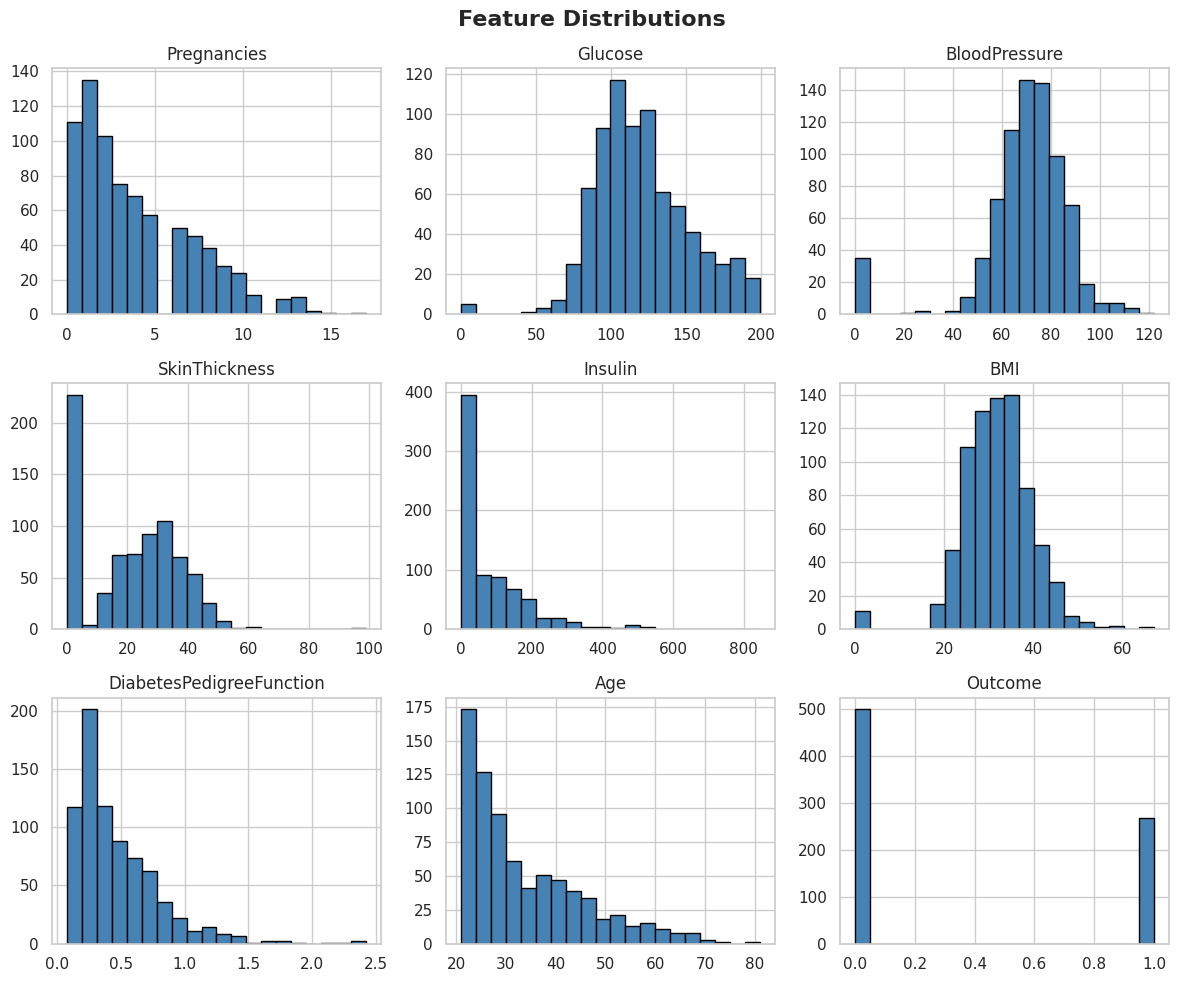

In [ ]:
# ── 2.3 Feature Distributions ───────────────────────────────────
df.hist(figsize=(12, 10), bins=20, color='steelblue', edgecolor='black')
plt.suptitle('Feature Distributions', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_02_feature_distributions.png', bbox_inches='tight')
plt.show()

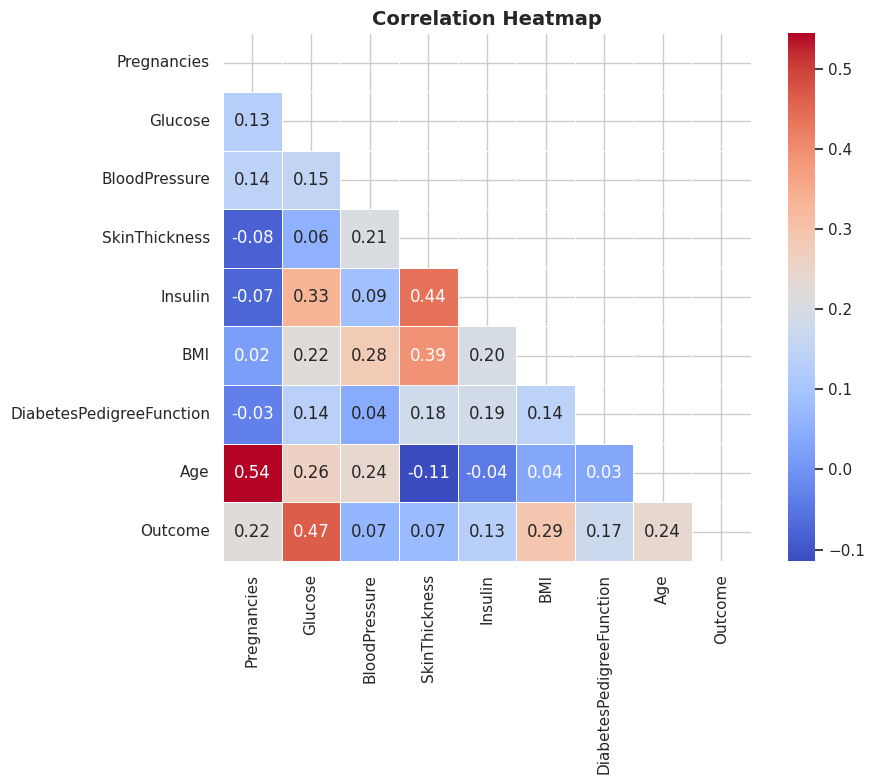

In [ ]:
# ── 2.4 Correlation Heatmap ──────────────────────────────────────
plt.figure(figsize=(10, 8))
mask = np.triu(np.ones_like(df.corr(), dtype=bool))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm',
            square=True, mask=mask, linewidths=0.5)
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_03_correlation_heatmap.png', bbox_inches='tight')
plt.show()

/tmp/ipykernel_14606/901296544.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Outcome', y=col, data=df, ax=axes[i], palette='Set2')
/tmp/ipykernel_14606/901296544.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(['No Diabetes', 'Diabetes'], rotation=15)
/tmp/ipykernel_14606/901296544.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Outcome', y=col, data=df, ax=axes[i], palette='Set2')
/tmp/ipykernel_14606/901296544.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xtickl

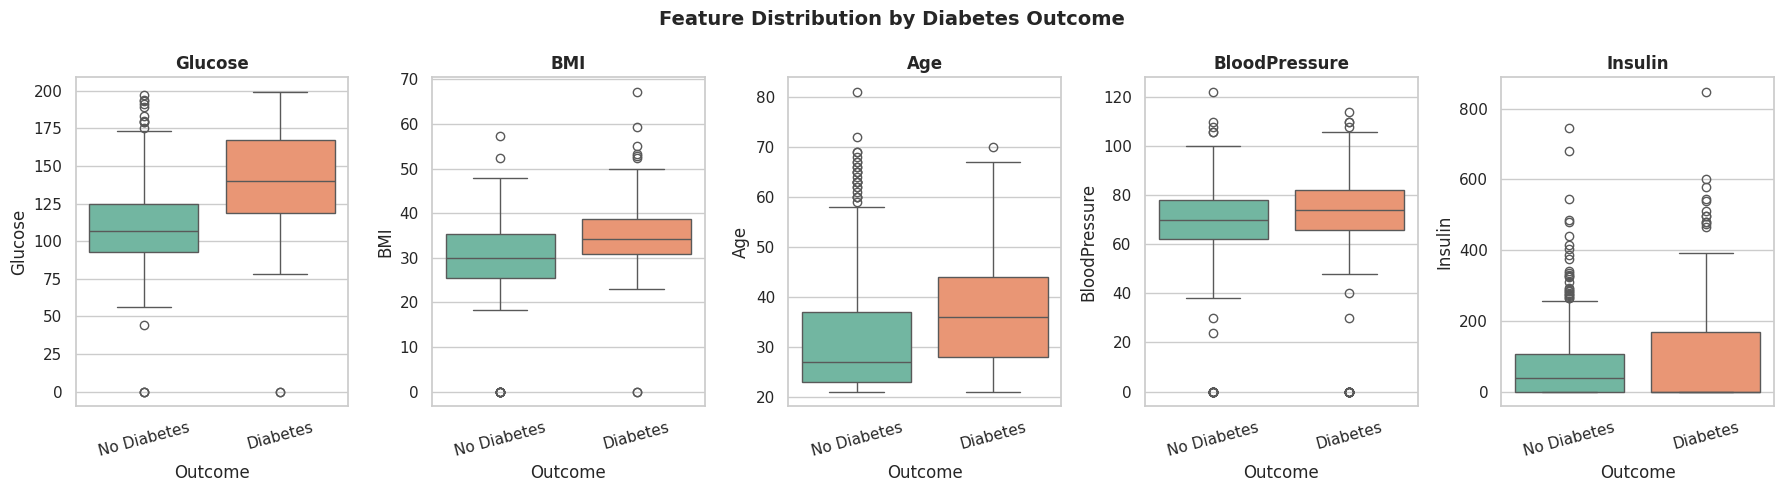

In [ ]:
# ── 2.5 Boxplots by Outcome ──────────────────────────────────────
features = ['Glucose', 'BMI', 'Age', 'BloodPressure', 'Insulin']

fig, axes = plt.subplots(1, 5, figsize=(18, 5))
for i, col in enumerate(features):
    sns.boxplot(x='Outcome', y=col, data=df, ax=axes[i], palette='Set2')
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xticklabels(['No Diabetes', 'Diabetes'], rotation=15)
plt.suptitle('Feature Distribution by Diabetes Outcome', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_04_boxplots_by_outcome.png', bbox_inches='tight')
plt.show()

In [ ]:
# ── 2.6 Zero Values (Hidden Missing Data) ───────────────────────
# In this dataset, zeros in certain columns represent missing data,
# not actual measurements (e.g. a person cannot have 0 BMI or 0 Glucose)
zero_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']

print('=== Zero Values = Missing Data ===')
for col in zero_cols:
    zeros = (df[col] == 0).sum()
    pct = zeros / len(df) * 100
    print(f'{col:>15}: {zeros:>3} zeros ({pct:.1f}%)')

=== Zero Values = Missing Data ===
        Glucose:   5 zeros (0.7%)
  BloodPressure:  35 zeros (4.6%)
  SkinThickness: 227 zeros (29.6%)
        Insulin: 374 zeros (48.7%)
            BMI:  11 zeros (1.4%)


### 📝 EDA Key Findings

- **Class imbalance:** ~65% non-diabetic, ~35% diabetic — mild imbalance, manageable without resampling
- **Strongest predictors:** Glucose (r=0.47), BMI (r=0.29), Age (r=0.24)
- **Weakest predictors:** BloodPressure and SkinThickness show little difference between groups
- **Hidden missing data:** Several columns use 0 as a placeholder for missing values — especially Insulin (48.7%) and SkinThickness (29.6%). This must be addressed in preprocessing.

---
## 3. Data Cleaning & Preprocessing

In [ ]:
# ── 3.1 Replace Zeros with NaN ───────────────────────────────────
df_clean = df.copy()  # always preserve the original
df_clean[zero_cols] = df_clean[zero_cols].replace(0, np.nan)

print('Missing values after replacing zeros:')
print(df_clean.isnull().sum())

Missing values after replacing zeros:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


In [ ]:
# ── 3.2 Impute with Median ───────────────────────────────────────
# Median is preferred over mean for skewed distributions
for col in zero_cols:
    median_val = df_clean[col].median()
    df_clean[col].fillna(median_val, inplace=True)

print('Missing values after imputation:')
print(df_clean.isnull().sum())
print('\n✅ No more missing values!')

Missing values after imputation:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

✅ No more missing values!


/tmp/ipykernel_14606/563496350.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean[col].fillna(median_val, inplace=True)


In [ ]:
# ── 3.3 Separate Features & Target ──────────────────────────────
X = df_clean.drop('Outcome', axis=1)
y = df_clean['Outcome']

print('Features (X) shape:', X.shape)
print('Target  (y) shape:', y.shape)
print('\nFeature columns:', list(X.columns))

Features (X) shape: (768, 8)
Target  (y) shape: (768,)

Feature columns: ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']


In [ ]:
# ── 3.4 Scale Features ───────────────────────────────────────────
# StandardScaler: mean=0, std=1 for each feature
# Required for Logistic Regression to converge properly
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

print('Scaled feature sample:')
X_scaled.head()

Scaled feature sample:


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,0.64,0.87,-0.03,0.67,-0.18,0.17,0.47,1.43
1,-0.84,-1.21,-0.53,-0.01,-0.18,-0.85,-0.37,-0.19
2,1.23,2.02,-0.69,-0.01,-0.18,-1.33,0.60,-0.11
3,-0.84,-1.07,-0.53,-0.70,-0.54,-0.63,-0.92,-1.04
4,-1.14,0.50,-2.68,0.67,0.32,1.55,5.48,-0.02


In [ ]:
# ── 3.5 Train / Test Split ───────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y,
    test_size=0.2,    # 80% train, 20% test
    random_state=42,  # reproducibility
    stratify=y        # preserve class balance in both splits
)

print('Training set:', X_train.shape)
print('Test set:    ', X_test.shape)
print('\nClass balance in training set:')
print(y_train.value_counts(normalize=True).round(3))

Training set: (614, 8)
Test set:     (154, 8)

Class balance in training set:
Outcome
0   0.65
1   0.35
Name: proportion, dtype: float64


In [ ]:
# ── 3.6 Preprocessing Summary ────────────────────────────────────
print('=== Preprocessing Summary ===')
print(f'  Original shape   : {df.shape}')
print(f'  Cleaned shape    : {df_clean.shape}')
print(f'  Training samples : {X_train.shape[0]}')
print(f'  Test samples     : {X_test.shape[0]}')
print(f'  Features used    : {X_train.shape[1]}')


=== Preprocessing Summary ===
  Original shape   : (768, 9)
  Cleaned shape    : (768, 9)
  Training samples : 614
  Test samples     : 154
  Features used    : 8


---
## 4. Model Building & Evaluation

We compare two models:
- **Logistic Regression** — simple, interpretable baseline
- **Random Forest** — ensemble method, typically higher accuracy

In [ ]:
# ── 4.1 Train Both Models ────────────────────────────────────────
lr = LogisticRegression(random_state=42, max_iter=1000)
rf = RandomForestClassifier(n_estimators=100, random_state=42)

lr.fit(X_train, y_train)
rf.fit(X_train, y_train)



RandomForestClassifier(random_state=42)

In [ ]:
# ── 4.2 Predictions ──────────────────────────────────────────────
lr_pred  = lr.predict(X_test)
rf_pred  = rf.predict(X_test)
lr_proba = lr.predict_proba(X_test)[:, 1]
rf_proba = rf.predict_proba(X_test)[:, 1]

print('=== Logistic Regression ===')
print(f'Accuracy : {accuracy_score(y_test, lr_pred):.4f}')
print(f'ROC-AUC  : {roc_auc_score(y_test, lr_proba):.4f}')
print()
print('=== Random Forest ===')
print(f'Accuracy : {accuracy_score(y_test, rf_pred):.4f}')
print(f'ROC-AUC  : {roc_auc_score(y_test, rf_proba):.4f}')

=== Logistic Regression ===
Accuracy : 0.7013
ROC-AUC  : 0.8128

=== Random Forest ===
Accuracy : 0.7792
ROC-AUC  : 0.8191


In [ ]:
# ── 4.3 Classification Reports ───────────────────────────────────
print('=== Logistic Regression — Classification Report ===')
print(classification_report(y_test, lr_pred, target_names=['No Diabetes', 'Diabetes']))

print('=== Random Forest — Classification Report ===')
print(classification_report(y_test, rf_pred, target_names=['No Diabetes', 'Diabetes']))

=== Logistic Regression — Classification Report ===
              precision    recall  f1-score   support

 No Diabetes       0.75      0.81      0.78       100
    Diabetes       0.59      0.50      0.54        54

    accuracy                           0.70       154
   macro avg       0.67      0.66      0.66       154
weighted avg       0.69      0.70      0.70       154

=== Random Forest — Classification Report ===
              precision    recall  f1-score   support

 No Diabetes       0.80      0.88      0.84       100
    Diabetes       0.73      0.59      0.65        54

    accuracy                           0.78       154
   macro avg       0.76      0.74      0.75       154
weighted avg       0.77      0.78      0.77       154



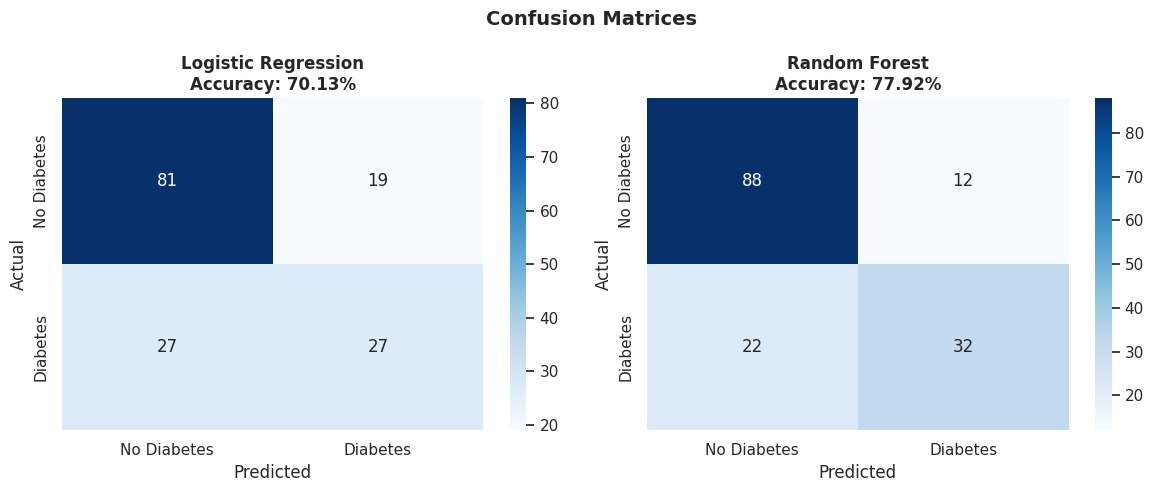

In [ ]:
# ── 4.4 Confusion Matrices ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, pred, title in zip(axes,
                            [lr_pred, rf_pred],
                            ['Logistic Regression', 'Random Forest']):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Diabetes', 'Diabetes'],
                yticklabels=['No Diabetes', 'Diabetes'])
    ax.set_title(f'{title}\nAccuracy: {accuracy_score(y_test, pred):.2%}',
                 fontweight='bold')
    ax.set_ylabel('Actual')
    ax.set_xlabel('Predicted')

plt.suptitle('Confusion Matrices', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_05_confusion_matrices.png', bbox_inches='tight')
plt.show()

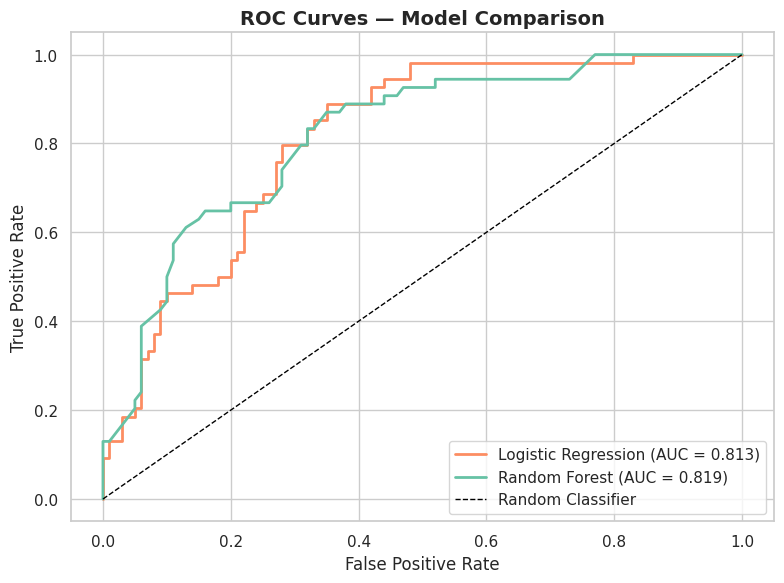

In [ ]:
# ── 4.5 ROC Curves ───────────────────────────────────────────────
plt.figure(figsize=(8, 6))

for proba, label, color in [
    (lr_proba, 'Logistic Regression', '#fc8d62'),
    (rf_proba, 'Random Forest',       '#66c2a5')
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f'{label} (AUC = {auc:.3f})', color=color, lw=2)

plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Model Comparison', fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('plot_06_roc_curves.png', bbox_inches='tight')
plt.show()

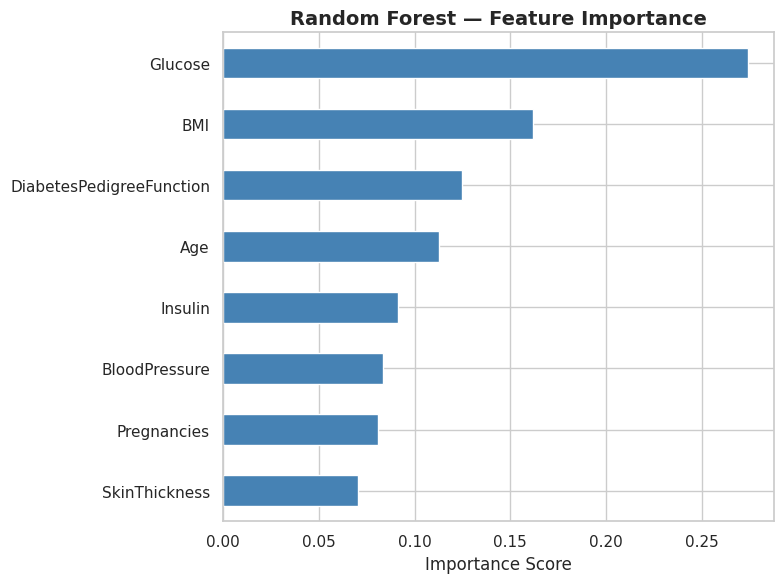


Top 3 most important features:
Glucose                    0.27
BMI                        0.16
DiabetesPedigreeFunction   0.13
dtype: float64


In [ ]:
# ── 4.6 Feature Importance (Random Forest) ───────────────────────
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=True)

plt.figure(figsize=(8, 6))
importances.plot(kind='barh', color='steelblue', edgecolor='white')
plt.title('Random Forest — Feature Importance', fontsize=14, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('plot_07_feature_importance.png', bbox_inches='tight')
plt.show()

print('\nTop 3 most important features:')
print(importances.sort_values(ascending=False).head(3))

In [ ]:
# ── 4.7 Cross-Validation ─────────────────────────────────────────
for model, name in [(lr, 'Logistic Regression'), (rf, 'Random Forest')]:
    cv_scores = cross_val_score(model, X_scaled, y, cv=5, scoring='accuracy')
    print(f'{name}')
    print(f'  CV Scores : {cv_scores.round(3)}')
    print(f'  Mean ± Std: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}\n')

Logistic Regression
  CV Scores : [0.76  0.747 0.786 0.797 0.771]
  Mean ± Std: 0.772 ± 0.018

Random Forest
  CV Scores : [0.766 0.74  0.74  0.83  0.745]
  Mean ± Std: 0.764 ± 0.034



In [ ]:
# ── 4.8 Final Model Comparison Table ─────────────────────────────
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Accuracy': [
        round(accuracy_score(y_test, lr_pred), 4),
        round(accuracy_score(y_test, rf_pred), 4)
    ],
    'ROC-AUC': [
        round(roc_auc_score(y_test, lr_proba), 4),
        round(roc_auc_score(y_test, rf_proba), 4)
    ]
})

print('=== Final Model Comparison ===')
results

=== Final Model Comparison ===


,Model,Accuracy,ROC-AUC
0,Logistic Regression,0.70,0.81
1,Random Forest,0.78,0.82


In [ ]:
from google.colab import files
files.download('plot_01_class_distribution.png')
files.download('plot_02_feature_distributions.png')
files.download('plot_03_correlation_heatmap.png')
files.download('plot_04_boxplots_by_outcome.png')
files.download('plot_05_confusion_matrices.png')
files.download('plot_06_roc_curves.png')
files.download('plot_07_feature_importance.png')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
## 5. Business Insights & Conclusions

### 🏆 Best Model
Based on both Accuracy and ROC-AUC scores, **Random Forest** outperforms Logistic Regression on this dataset.

### 🔑 Key Predictors of Diabetes
Feature importance analysis confirms the EDA findings:
1. **Glucose** — the single strongest predictor
2. **BMI** — second most important indicator
3. **Age** — older patients at significantly higher risk

### 💼 Business Recommendations
- **Prioritize glucose screening** in routine check-ups — it is the most reliable early indicator
- **Target BMI reduction programs** at high-risk patients (BMI > 30)
- **Age-based risk stratification:** patients over 40 should receive more frequent diabetes screening
- Deploy this model as a **clinical decision support tool** to flag at-risk patients for follow-up

### ⚠️ Limitations
- Dataset limited to Pima Indian women — model may not generalize to other populations
- High proportion of missing Insulin data (48.7%) limits predictive power of that feature
- A larger, more diverse dataset would improve reliability

### 🤖 Ethics & Responsible AI
- **Bias risk:** Model trained exclusively on one demographic group — applying it broadly could produce unfair outcomes for other ethnic groups
- **Fairness:** Model should not be used to deny insurance or treatment — only to recommend additional screening
- **Transparency:** Logistic Regression offers a more explainable alternative if clinicians need to justify predictions
- **Privacy:** Patient data must be anonymized and handled under HIPAA guidelines